In [1]:
# Load the data
experience=[14,29,6,25,18,4,18,12,22,6,30,11,30,5,20,13,9,32,24,13,19,4,28,22,8]
result=[0,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0,0,1,1,1]

In [2]:
# Load a Plotting Tool
import matplotlib.pyplot as plt
def make1plot(listx1,listy1,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()
def make2plot(listx1,listy1,listx2,listy2,strlablx,strlably,strtitle):
    mydata = plt.figure(figsize = (6,6)) # build a square drawing canvass from figure class
    plt.plot(listx1,listy1, c='red', marker='o',linewidth=0) # basic data plot
    plt.plot(listx2,listy2, c='blue',linewidth=1) # basic model plot
    plt.xlabel(strlablx)
    plt.ylabel(strlably)
    plt.legend(['Data','Model'])# modify for argument insertion
    plt.title(strtitle)
    plt.grid(axis='y')
    plt.show()

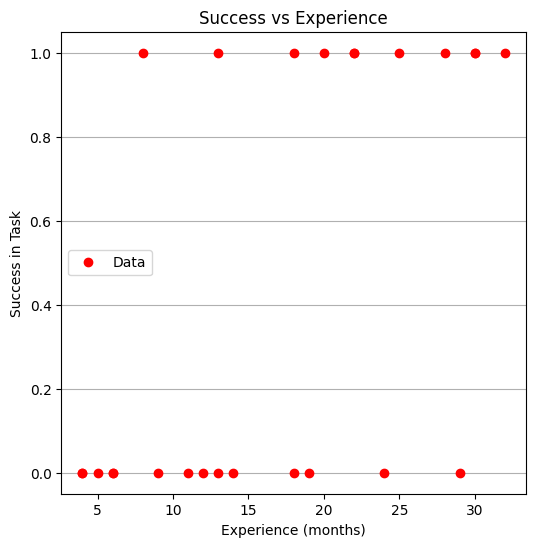

In [3]:
make1plot(experience,result,"Experience (months)","Success in Task","Success vs Experience")

In [4]:
def pii(b0,b1,x): #sigmoidal function
    import math
    pii = math.exp(b0+b1*x)/(1+ math.exp(b0+b1*x))
    return(pii)

def sse(mod,obs): #compute sse from observations and model values
    howmany = len(mod)
    sse=0.0
    for i in range(howmany):
        sse=sse+(mod[i]-obs[i])**2
    return(sse)

def merit(beta): # merit function to minimize
    global result,experience #access lists already defined external to function
    mod=[0 for i in range(len(experience))]
    for i in range(len(experience)):
        mod[i]=pii(beta[0],beta[1],experience[i])
    merit = sse(mod,result)
    return(merit)

In [5]:
beta = [0,0] #initial guess of betas
merit(beta) #check that does not raise an exception

6.25

In [6]:
import numpy as np
from scipy.optimize import minimize

#x0 = np.array([-3.0597,0.1615])
x0 = np.array(beta)
res = minimize(merit, x0, method='powell',options={'disp': True})

Optimization terminated successfully.
         Current function value: 4.199713
         Iterations: 5
         Function evaluations: 132


 b0 =  -2.982390266878914
 b1 =  0.15954743797099522


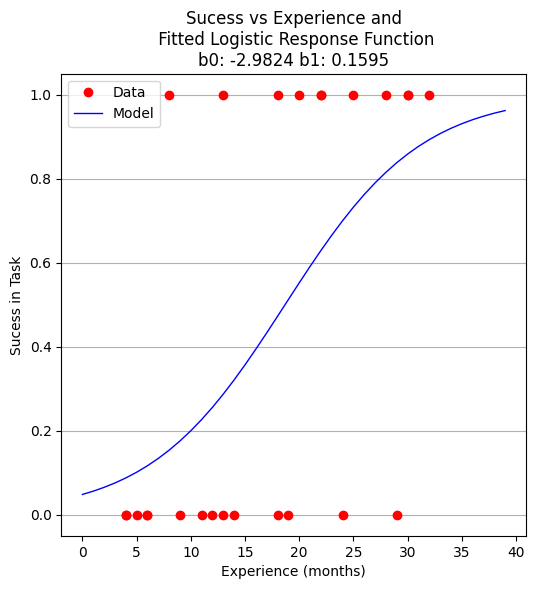

In [7]:
fitted=[0 for i in range(40)]
xaxis =[0 for i in range(40)]
beta[0]=res.x[0]
beta[1]=res.x[1]
for i in range(40):
    xaxis[i]=float(i)
    fitted[i]=pii(res.x[0],res.x[1],float(i))
    
print(" b0 = ",res.x[0])
print(" b1 = ",res.x[1])
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n'+'b0: '+ str(round(res.x[0],4))+ ' b1: ' +str(round(res.x[1],4))
make2plot(experience,result,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

In [8]:
guess = 25.5
pii(res.x[0],res.x[1],guess)

0.7476408418994896

In [9]:
guess = 18.75
pii(res.x[0],res.x[1],guess)

0.5022810329444896

In [10]:
# import the class
import numpy
from sklearn.linear_model import LogisticRegression
X = numpy.array(experience)
y = numpy.array(result)
# instantiate the model (using the default parameters)
logreg = LogisticRegression(solver='lbfgs',max_iter=10000)
# fit the model with data  -TRAIN the model
logreg.fit(X.reshape(-1, 1),y)

LogisticRegression(max_iter=10000)

In [11]:
logreg.coef_

array([[0.16080665]])

In [12]:
xplot = numpy.array(xaxis)
y_pred=logreg.predict(xplot.reshape(-1,1))

b0 = logreg.intercept_[0]
b1 = logreg.coef_[0][0]



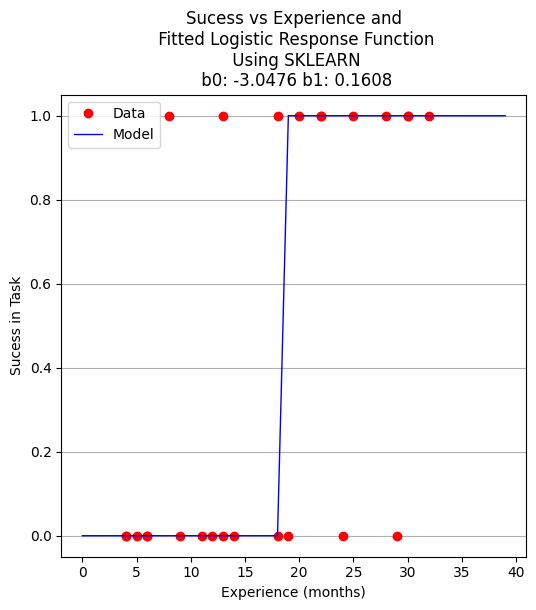

In [13]:
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using SKLEARN\n '+'b0: '+ str(round(b0,4)) + ' b1: ' + str(round(b1,4))
make2plot(experience,result,xplot,y_pred,'Experience (months)','Sucess in Task',plottitle)

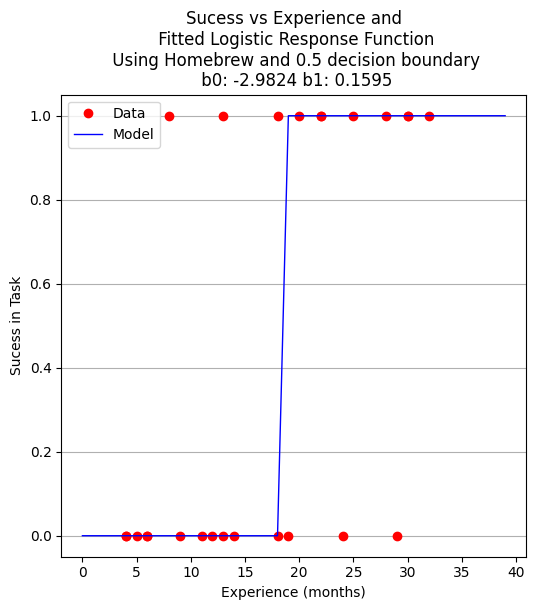

In [14]:
for i in range(40):
    xaxis[i]=float(i)
    fitted[i]=pii(beta[0],beta[1],float(i))
#    fitted[i]=pii(b0,b1,float(i))
    if fitted[i] > 0.5:
        fitted[i] = 1.0
    else:
        fitted[i]=0.0

plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using Homebrew and 0.5 decision boundary\n '+'b0: '+ str(round(beta[0],4)) + ' b1: ' + str(round(beta[1],4))
make2plot(experience,result,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=0)

In [16]:
# instantiate the model (using the default parameters)
logreg = LogisticRegression(solver='lbfgs',max_iter=10000)
# fit the model with data  -TRAIN the model
logreg.fit(X_train.reshape(-1, 1),y_train)

LogisticRegression(max_iter=10000)

In [17]:
xplot = numpy.array(xaxis)
y_pred=logreg.predict(X_test.reshape(-1,1))

b0 = logreg.intercept_[0]
b1 = logreg.coef_[0][0]

for i in range(40):
    xaxis[i]=float(i)
#    fitted[i]=pii(beta[0],beta[1],float(i))
    fitted[i]=pii(b0,b1,float(i))
    if fitted[i] > 0.5:
        fitted[i] = 1.0
    else:
        fitted[i]=0.0

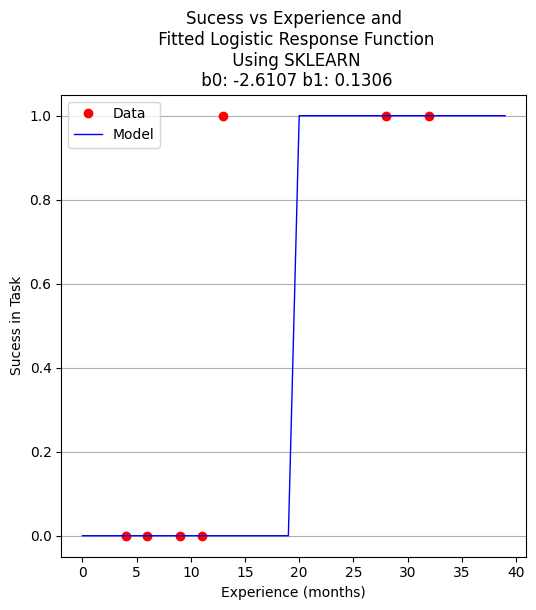

In [18]:
plottitle = 'Sucess vs Experience and\n Fitted Logistic Response Function\n Using SKLEARN\n '+'b0: '+ str(round(b0,4)) + ' b1: ' + str(round(b1,4))
make2plot(X_test,y_test,xaxis,fitted,'Experience (months)','Sucess in Task',plottitle)

In [19]:
# import the metrics class
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_pred, y_test)
cnf_matrix

array([[4, 1],
       [0, 2]])

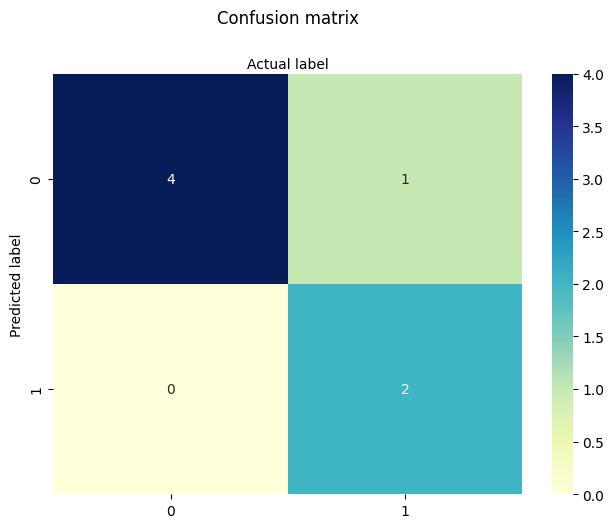

In [20]:
import seaborn as sns
import pandas as pd
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Predicted label')
plt.xlabel('Actual label');

In [21]:
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))
print("Precision:",metrics.precision_score(y_test, y_pred))
print("Recall:",metrics.recall_score(y_test, y_pred))
print("F1-score:",metrics.f1_score(y_test, y_pred))

Accuracy: 0.8571428571428571
Precision: 1.0
Recall: 0.6666666666666666
F1-score: 0.8


In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.67      0.80         3

    accuracy                           0.86         7
   macro avg       0.90      0.83      0.84         7
weighted avg       0.89      0.86      0.85         7



In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


In [24]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def make1plot(x, y, xlabel, ylabel, title):
    plt.figure(figsize=(6, 6))
    plt.plot(x, y, 'o')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()


In [25]:
# Simulate experience (months) and probability of success
np.random.seed(42)
experience = np.linspace(0, 12, 50).reshape(-1, 1)
true_params = [0.8, -4.5]
logit_score = true_params[0] * experience + true_params[1]
prob_success = sigmoid(logit_score)
result = np.random.binomial(1, prob_success.ravel())  # Binary outcome


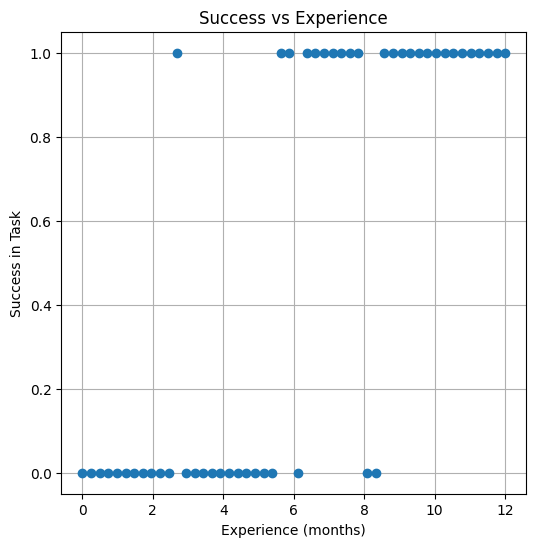

In [26]:
make1plot(experience, result, "Experience (months)", "Success in Task", "Success vs Experience")


In [27]:
model = LogisticRegression()
model.fit(experience, result)

# Predict probability over a finer grid
x_pred = np.linspace(0, 12, 200).reshape(-1, 1)
y_pred = model.predict_proba(x_pred)[:, 1]


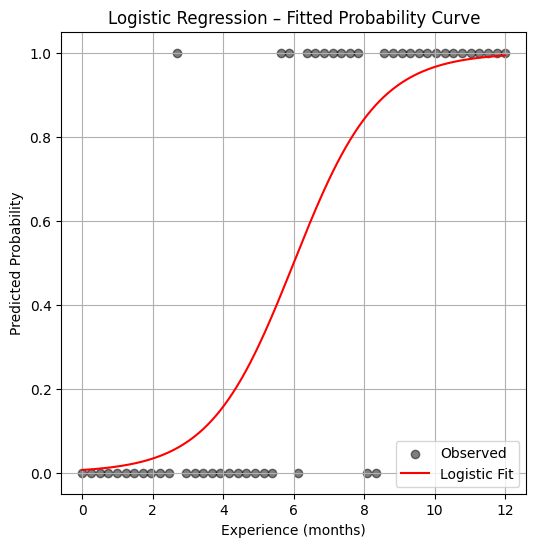

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(experience, result, label="Observed", color="black", alpha=0.5)
plt.plot(x_pred, y_pred, color="red", label="Logistic Fit")
plt.xlabel("Experience (months)")
plt.ylabel("Predicted Probability")
plt.title("Logistic Regression – Fitted Probability Curve")
plt.legend()
plt.grid(True)
plt.show()


In [29]:
y_pred_binary = model.predict(experience)
print(confusion_matrix(result, y_pred_binary))
print(classification_report(result, y_pred_binary))


[[22  3]
 [ 3 22]]
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        25
           1       0.88      0.88      0.88        25

    accuracy                           0.88        50
   macro avg       0.88      0.88      0.88        50
weighted avg       0.88      0.88      0.88        50

